In [1]:
import pandas as pd
import matplotlib.pyplot as mp

start_year=2017

In [2]:
def extractor(link:str):
    """
    Takes a given csv file as an input, and extracts it into data frame

    Arguments:
        link(str): URL of a CSV file to be extracted

    Returns:
        file: DataFrame formed after reading the CSV
    """
    file=pd.read_csv(link)
    if "name" in file.columns or "Name" in file.columns:#Replaces to"name" column so every data is homogeneous
         file.rename(columns={"Contestant": "Name"}, inplace=True)
    return file


In [3]:
def sum_of_columns(df):
    """
    Drops unnecessary Columns and sums up the numerical values contained in the raw
    dataframe

    Arguments:
        df: DataFrame extracted from CSV with raw unprocessed data

    Returns:
        df: DataFrame with processed columns and refined data
    """
    if "Year" in df.columns:
        df=df.drop(columns=["Year"])#Filters out a numerical data which is not required
    if "Award" in df.columns:
        df=df.drop(columns=["Award"])#Filters out a numerical data which is not required

    df=df.select_dtypes(include="number").sum()
    return df

In [4]:
def scores(score_for_years:list):
    """
    Takes list with sum of marks for multiple years and outputs the scores problem wise

    Arguments:
        score_for_years(list)- List of Problem wise cumulative scores for different years, with a single item in the list representing a year.

    Returns:
        individual scores(list): Dictionary of problem wise scores where each key represents scores across the years for a single problem

    """
    individual_scores={"P1":[],"P2":[],"P3":[],"P4":[],"P5":[],"P6":[], "Total":[]}#Different data for various problems across multiple years  is saved here
    for yearly_scores in score_for_years:
        for problems in individual_scores.keys():
            individual_scores[problems].append(yearly_scores.loc[problems])
    return individual_scores

In [5]:
def make_frame(question, name, years:list):
    """
    Takes data for different years and outputs seperate dataframe for each problem across different years

    Arguments:
        question: The cumulative problem-wise marks for different years.
        name: The name of the question for which data is stored.
        years(list): List of years for which data was collected.
    """
    data=[]
    for score in question:
        data.append(score)
    show_data=pd.DataFrame({name:data}, index=years)
    return show_data

In [6]:
files = [
    "2017.csv", "2018.csv", "2019.csv", "2020.csv",
    "2021.csv", "2022.csv", "imo_2023_official_nepal.csv",
    "2024res.csv", "imo 2025.csv"
]#list of IMO data to be extracted into csv from 2017 to 2025


yearly_results = []#The data for each year from 2017-2025 is saved here.

# Loop through every file and add its sum to the list
for file in files:
    df = extractor(file)
    yearly_sum = sum_of_columns(df)
    yearly_results.append(yearly_sum)


all_data = scores(yearly_results)

In [7]:
years_involved=[]#stores the name of years for which data was collected(can be changed manually if inconsistent data)
year=start_year
for results in yearly_results:
    years_involved.append(year)
    year+=1

every_year_datas=[]#stores the list of dataframe across ears problem wise
for problem in all_data.keys():
    all_years=make_frame(all_data[problem], problem, years_involved)
    every_year_datas.append(all_years)


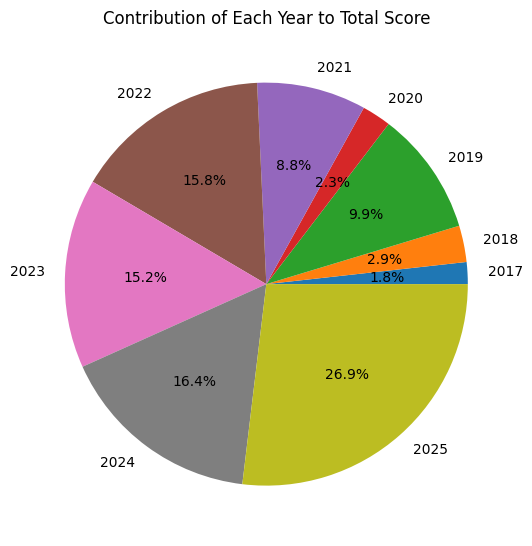

In [8]:
mp.figure(figsize=(6.5,7))
every_year_datas[-1]["Total"].plot(
    kind="pie",#Forms a pie chart with total scores achieved by the country with a single data representing a single year.
    autopct="%1.1f%%"
)

mp.title("Contribution of Each Year to Total Score")
mp.savefig("total_scores_pie.png", dpi=250)


The codes below combines data for three problems( Pro to form a line graph representing three scores across 9 years. It is  used to compare data for different questions in the report. The three problems are P1,P2 and P3.

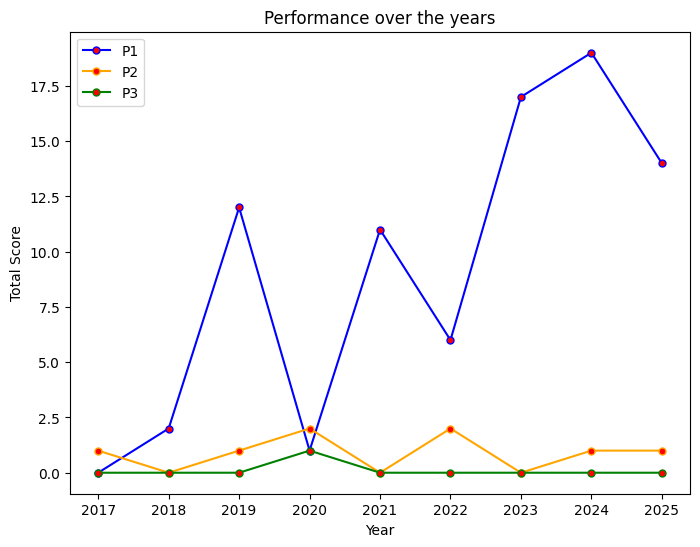

In [9]:
mp.figure(figsize=(8,6))

mp.plot(every_year_datas[0], label="P1", color="blue", marker=".", markersize=10, markerfacecolor="red")#Plots for Problem 1
mp.plot(every_year_datas[1], label="P2", color="orange",marker=".", markersize=10, markerfacecolor="red")#Plots for Problem 2
mp.plot(every_year_datas[2], label="P3", color="green", marker=".", markersize=10, markerfacecolor="red")#Plots for Problem 3
mp.xlabel("Year")
mp.ylabel("Total Score")
mp.title("Performance over the years")

mp.legend()
mp.savefig("year1_3.png", dpi=2500)

mp.show()


The codes below combines data for three problems( Pro to form a line graph representing three scores across 9 years. It is  used to compare data for different questions in the report. The three problems are P4,P5 and P6.

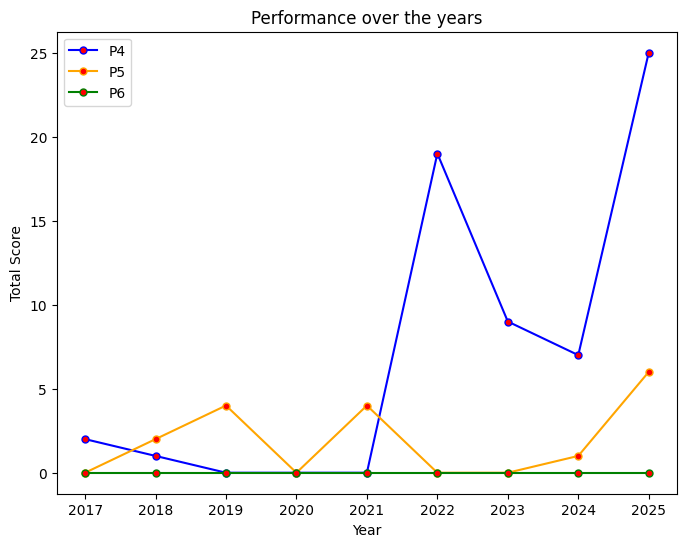

In [10]:

mp.figure(figsize=(8,6))

mp.plot(every_year_datas[3], label="P4", color="blue", marker=".", markersize=10, markerfacecolor="red")#Plots for problem 4
mp.plot(every_year_datas[4], label="P5", color="orange",marker=".", markersize=10, markerfacecolor="red")#Plots for problem 5
mp.plot(every_year_datas[5], label="P6", color="green", marker=".", markersize=10, markerfacecolor="red")#Plots for problem 6
mp.xlabel("Year")
mp.ylabel("Total Score")
mp.title("Performance over the years")

mp.legend()
mp.savefig("year4_6.png", dpi=2500)
mp.show()
